# Logistic Regression: Mexico GDP Growth Model (1960–2021)
## Regresión Logística: Modelo de Crecimiento del PIB de México

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** Mexico GDP 1960–2021 — World Bank (`Mexico GDP.xlsx`)  
**Source / Fuente:** [Banco Mundial — data.worldbank.org](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD?locations=MX)

**Objective / Objetivo:**  
EN · Fit a logistic (S-curve) growth model to Mexico's historical GDP data using non-linear least squares, compare it against a linear regression baseline, and generate a GDP forecast through 2040.

ES · Ajustar un modelo de crecimiento logístico (curva S) a los datos históricos del PIB de México mediante mínimos cuadrados no lineales, compararlo con una regresión lineal base y generar un pronóstico del PIB hasta 2040.

**Techniques / Técnicas:** Logistic Growth Model · Non-linear Least Squares · scipy.optimize · Linear vs Logistic comparison · Forecasting  
**Libraries / Librerías:** `pandas` · `numpy` · `scipy` · `matplotlib`

---

# Importar librerías

In [2]:
# ============================================================
# ANÁLISIS DE REGRESIÓN LOGÍSTICA - PIB MÉXICO
# Fuente: Banco Mundial
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Cargar y observar datos

In [3]:
# ============================================================
# CARGA DE DATOS
# ============================================================

# Datos del PIB de México (Banco Mundial)
df = pd.read_excel('data/Mexico GDP.xlsx')

print('=' * 65)
print("DATOS HISTÓRICOS - PIB MÉXICO (USD)")
print('=' * 65)
print(df.to_string(index=False))
print('─' * 55)
print(f"\n• Dimensiones del DataFrame: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f'• Período: {df['Periodo'].min()} - {df['Periodo'].max()}')
print(f'• PIB máximo: ${df['GDP'].max():,.2f}')
print(f'• PIB mínimo: ${df['GDP'].min():,.2f}')

print(f'\nEstadísticas Generales:')
print('─' * 38)
print(df.describe())
print('─' * 38)

DATOS HISTÓRICOS - PIB MÉXICO (USD)
 Periodo          GDP
    1960 1.304000e+10
    1961 1.416000e+10
    1962 1.520000e+10
    1963 1.696000e+10
    1964 2.008000e+10
    1965 2.184000e+10
    1966 2.432000e+10
    1967 2.656000e+10
    1968 2.936000e+10
    1969 3.248000e+10
    1970 3.552000e+10
    1971 3.920000e+10
    1972 4.520000e+10
    1973 5.528000e+10
    1974 7.200000e+10
    1975 8.800000e+10
    1976 8.902597e+10
    1977 8.181416e+10
    1978 1.025000e+11
    1979 1.345614e+11
    1980 2.051391e+11
    1981 2.639593e+11
    1982 1.846092e+11
    1983 1.561592e+11
    1984 1.842615e+11
    1985 1.952198e+11
    1986 1.345501e+11
    1987 1.475407e+11
    1988 1.816115e+11
    1989 2.214007e+11
    1990 2.612536e+11
    1991 3.131428e+11
    1992 3.631576e+11
    1993 5.007361e+11
    1994 5.278132e+11
    1995 3.600739e+11
    1996 4.109756e+11
    1997 5.004135e+11
    1998 5.265021e+11
    1999 6.002329e+11
    2000 7.079067e+11
    2001 7.567063e+11
    2002 7.721064e

# Visualización de datos originales

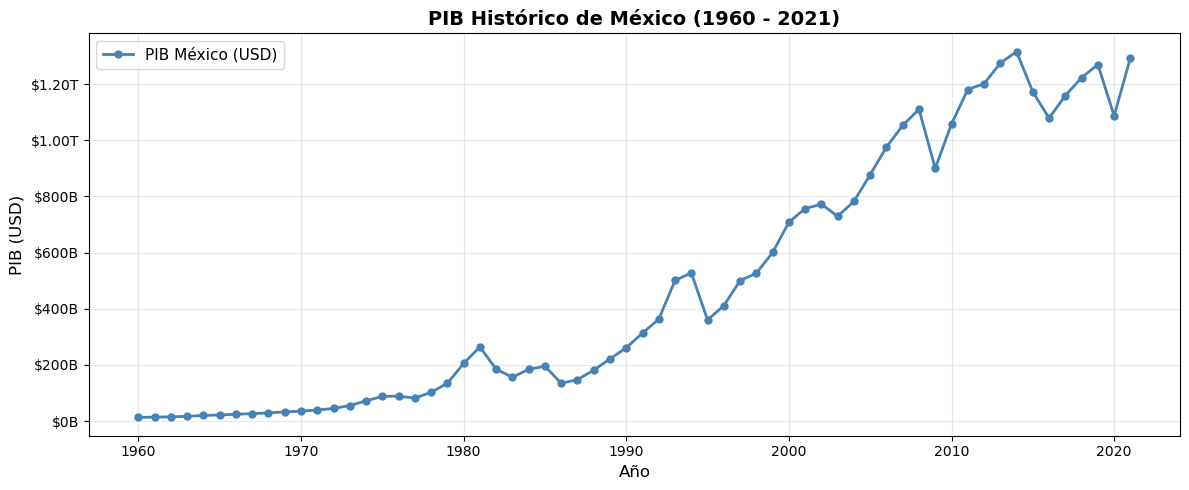

In [4]:
# ============================================================
# VISUALIZACIÓN DE DATOS ORIGINALES
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['Periodo'], df['GDP'], 'o-', color='steelblue',
        linewidth=2, markersize=5, label='PIB México (USD)')

ax.set_title('PIB Histórico de México (1960 - 2021)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('PIB (USD)', fontsize=12)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e12:.2f}T' if x >= 1e12 else f'${x/1e9:.0f}B') # Dividir el PIB entre 1e12 y 1e9 para que los números en el eje Y sean más legibles
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pib_original.png', dpi=150)
plt.show()

# Ajuste con datos SIN normalizar

In [5]:
# ===============================================================
# AJUSTE LOGÍSTICO CON DATOS ORIGINALES (SIN NORMALIZAR)
# Modelo: Y = 1 / (1 + exp(β1 + β2 * X))
# ===============================================================

def modelo_logistico(X, beta1, beta2):
    return 1.0 / (1.0 + np.exp(beta1 + beta2 * X))

X_raw = df['Periodo'].values.astype(float)
Y_raw = df['GDP'].values.astype(float)

print('=' * 65)
print('AJUSTE CON DATOS ORIGINALES (SIN NORMALIZAR)')
print('=' * 65)

try:
    params_raw, cov_raw = curve_fit(
        modelo_logistico,
        X_raw,
        Y_raw,
        p0=[1.0, -0.001],       # Valores iniciales
        maxfev=10_000
    )
    beta1_raw, beta2_raw = params_raw
    print(f'\nConvergencia lograda (aunque con posibles problemas numéricos)')
    print(f'   β1 = {beta1_raw:.6e}')
    print(f'   β2 = {beta2_raw:.6e}')

    Y_pred_raw = modelo_logistico(X_raw, beta1_raw, beta2_raw)
    r2_raw = r2_score(Y_raw, Y_pred_raw)
    print(f'   R² = {r2_raw:.6f}')

except Exception as e:
    print(f"\nERROR AL AJUSTAR CON DATOS ORIGINALES:")
    print(f"   {e}")

AJUSTE CON DATOS ORIGINALES (SIN NORMALIZAR)

Convergencia lograda (aunque con posibles problemas numéricos)
   β1 = 1.000000e+00
   β2 = -1.000000e-03
   R² = -1.165208


¿Convergió el optimizador?   → SÍ (técnicamente)
¿El ajuste es bueno?         → NO

El modelo logístico SIEMPRE produce valores entre 0 y 1 (por definición matemática)

El PIB real está en escala de 10¹²

El optimizador "se rindió" y devolvió los valores iniciales (β1=1.0, β2=-0.001) porque  NINGUNA combinación de β1 y β2 puede hacer que Y = 1/(1+eˣ) alcance valores de 10¹²

R² = -1.165 → CONFIRMA que el modelo no sirve

SOLUCIÓN → Normalizar los datos

# Normalización de datos

In [6]:
# ================================================================================================
# NORMALIZACIÓN DE DATOS
# Para Periodo: (X - X_min) / (X_max - X_min) ← X queda en rango [0, 1]
# Para GDP: Y / max_Y * 1.001 ← con pequeño ajuste para evitar ln(0) → 0 < Y < 1 estrictamente          
# ================================================================================================

# Valores mínimos y máximos
min_X = df['Periodo'].min()   # 1960
max_X = df['Periodo'].max()   # 2021
max_Y = df['GDP'].max()       # PIB máximo en el período

# Normalización
df['Periodo_norm'] = (df['Periodo'] - min_X) / (max_X - min_X)
max_Y_ajustado = max_Y * 1.001
df['GDP_norm'] = df['GDP'] / max_Y_ajustado

print('=' * 65)
print('DATOS NORMALIZADOS')
print('=' * 65)
print(f'  • Periodo Máximo: {max_X}   |   Periodo Mínimo: = {min_X}')
print(f'  • GDP Máximo: ${max_Y:,.2f}')
print('─' * 55)
print(df[['Periodo', 'Periodo_norm', 'GDP', 'GDP_norm']].to_string(index=False))
print("─" * 55)
print(f'  • Rango Periodo Normalizado: [{df['Periodo_norm'].min():.4f}, {df['Periodo_norm'].max():.4f}]')
print(f'  • Rango GDP Normalizado: [{df['GDP_norm'].min():.6f}, {df['GDP_norm'].max():.6f}]')
print("─" * 55)

DATOS NORMALIZADOS
  • Periodo Máximo: 2021   |   Periodo Mínimo: = 1960
  • GDP Máximo: $1,315,351,183,524.54
───────────────────────────────────────────────────────
 Periodo  Periodo_norm          GDP  GDP_norm
    1960      0.000000 1.304000e+10  0.009904
    1961      0.016393 1.416000e+10  0.010754
    1962      0.032787 1.520000e+10  0.011544
    1963      0.049180 1.696000e+10  0.012881
    1964      0.065574 2.008000e+10  0.015251
    1965      0.081967 2.184000e+10  0.016587
    1966      0.098361 2.432000e+10  0.018471
    1967      0.114754 2.656000e+10  0.020172
    1968      0.131148 2.936000e+10  0.022299
    1969      0.147541 3.248000e+10  0.024668
    1970      0.163934 3.552000e+10  0.026977
    1971      0.180328 3.920000e+10  0.029772
    1972      0.196721 4.520000e+10  0.034329
    1973      0.213115 5.528000e+10  0.041985
    1974      0.229508 7.200000e+10  0.054684
    1975      0.245902 8.800000e+10  0.066835
    1976      0.262295 8.902597e+10  0.067615
    1

# Ajuste con datos normalizados

In [7]:
# ============================================================
# AJUSTE LOGÍSTICO CON DATOS NORMALIZADOS
# Y = 1 / (1 + exp(β1 + β2·X))
# ============================================================

# Definición del modelo logístico
def modelo_logistico(X, beta1, beta2):
    return 1.0 / (1.0 + np.exp(beta1 + beta2 * X))
    
X_norm = df['Periodo_norm'].values # rango [0, 1]
Y_norm = df['GDP_norm'].values     # rango (0, 1)

print('=' * 65)
print("AJUSTE CON DATOS NORMALIZADOS")
print('=' * 65)

try:
    params_norm, cov_norm = curve_fit(
        modelo_logistico,
        X_norm,
        Y_norm,
        p0=[5.0, -10.0],     # Valores iniciales aproximados
        maxfev=100_000,
        method='lm'           # Levenberg-Marquardt
    )

    beta1_norm, beta2_norm = params_norm
    perr = np.sqrt(np.diag(cov_norm))  # Error estándar de parámetros

    print(f"\n¡CONVERGENCIA EXITOSA!")
    print(f"   β1 = {beta1_norm:.6f}  (±{perr[0]:.6f})")
    print(f"   β2 = {beta2_norm:.6f}  (±{perr[1]:.6f})")

    # Predicciones
    Y_pred_norm = modelo_logistico(X_norm, beta1_norm, beta2_norm)

    # Métricas de bondad de ajuste
    r2 = r2_score(Y_norm, Y_pred_norm)
    rmse = np.sqrt(mean_squared_error(Y_norm, Y_pred_norm))
    mae = np.mean(np.abs(Y_norm - Y_pred_norm))
    r_pearson, p_valor = pearsonr(Y_norm, Y_pred_norm)
    ss_res = np.sum((Y_norm - Y_pred_norm)**2)
    ss_tot = np.sum((Y_norm - np.mean(Y_norm))**2)

    print("\n" + '─' * 45)
    print('MÉTRICAS DE BONDAD DE AJUSTE')
    print('─' * 45)
    print(f'   R²          = {r2:.6f} → {'★ Excelente' if r2>0.95 else '✓ Bueno' if r2>0.85 else '✗ Revisar'}')
    print(f'   R (Pearson) = {r_pearson:.6f} (p = {p_valor:.2e})')
    print(f'   RMSE (norm) = {rmse:.6f}')
    print(f'   MAE (norm)  = {mae:.6f}')
    print(f'   SS_res      = {ss_res:.6e}')
    print(f'   SS_tot      = {ss_tot:.6e}')
    print('─' * 45)

except Exception as e:
    print(f'ERROR: {e}')

AJUSTE CON DATOS NORMALIZADOS

¡CONVERGENCIA EXITOSA!
   β1 = 5.284229  (±0.226908)
   β2 = -8.184770  (±0.345591)

─────────────────────────────────────────────
MÉTRICAS DE BONDAD DE AJUSTE
─────────────────────────────────────────────
   R²          = 0.978048 → ★ Excelente
   R (Pearson) = 0.989258 (p = 8.10e-52)
   RMSE (norm) = 0.050728
   MAE (norm)  = 0.037924
   SS_res      = 1.595439e-01
   SS_tot      = 7.267894e+00
─────────────────────────────────────────────


# Gráfica del ajuste normalizado

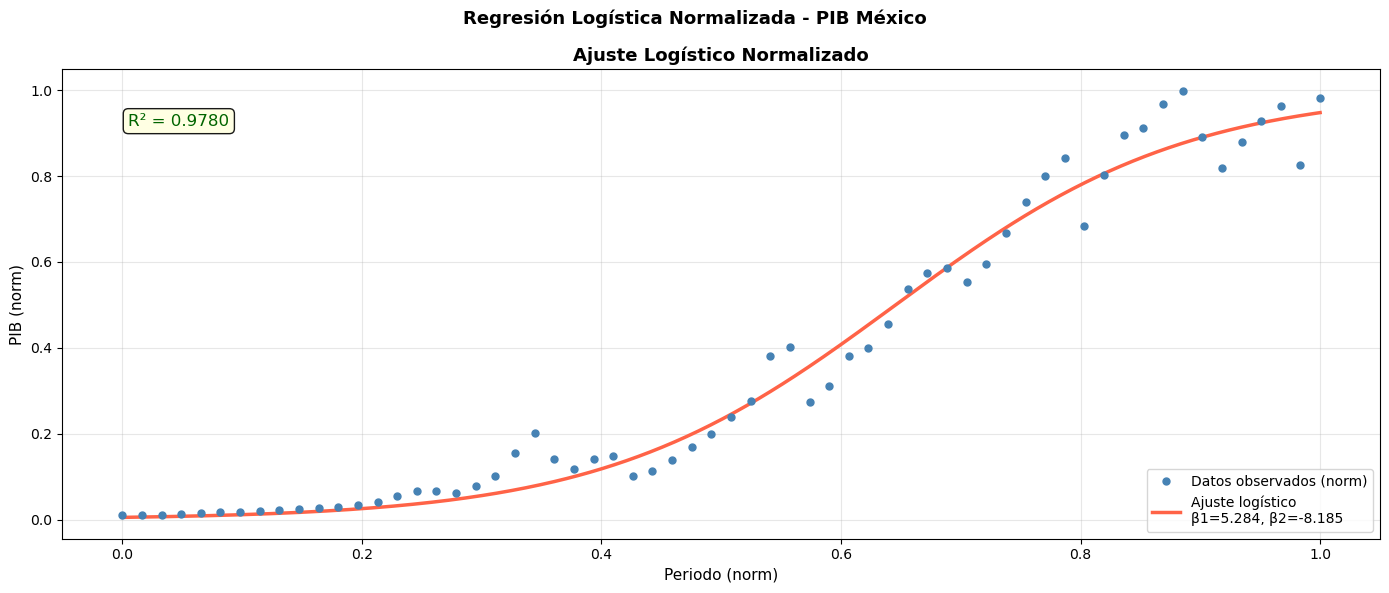

In [21]:
# ============================================================
# VISUALIZACIÓN DEL AJUSTE NORMALIZADO
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

X_linea = np.linspace(X_norm.min(), X_norm.max(), 500)
Y_linea = modelo_logistico(X_linea, beta1_norm, beta2_norm)

ax.plot(X_norm, Y_norm,
         'o', color='steelblue', markersize=5,
         label='Datos observados (norm)', zorder=5)
ax.plot(X_linea, Y_linea, '-', color='tomato', linewidth=2.5,
         label=f'Ajuste logístico\nβ1={beta1_norm:.3f}, β2={beta2_norm:.3f}')
ax.set_title('Ajuste Logístico Normalizado', fontsize=13, fontweight='bold')
ax.set_xlabel('Periodo (norm)', fontsize=11)
ax.set_ylabel('PIB (norm)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.88, f'R² = {r2:.4f}',
         transform=ax.transAxes, fontsize=12, color='darkgreen',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle('Regresión Logística Normalizada - PIB México',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ajuste_logistico_normalizado_2.png', dpi=150, bbox_inches='tight')
plt.show()

# Gráfica del ajuste en escala original

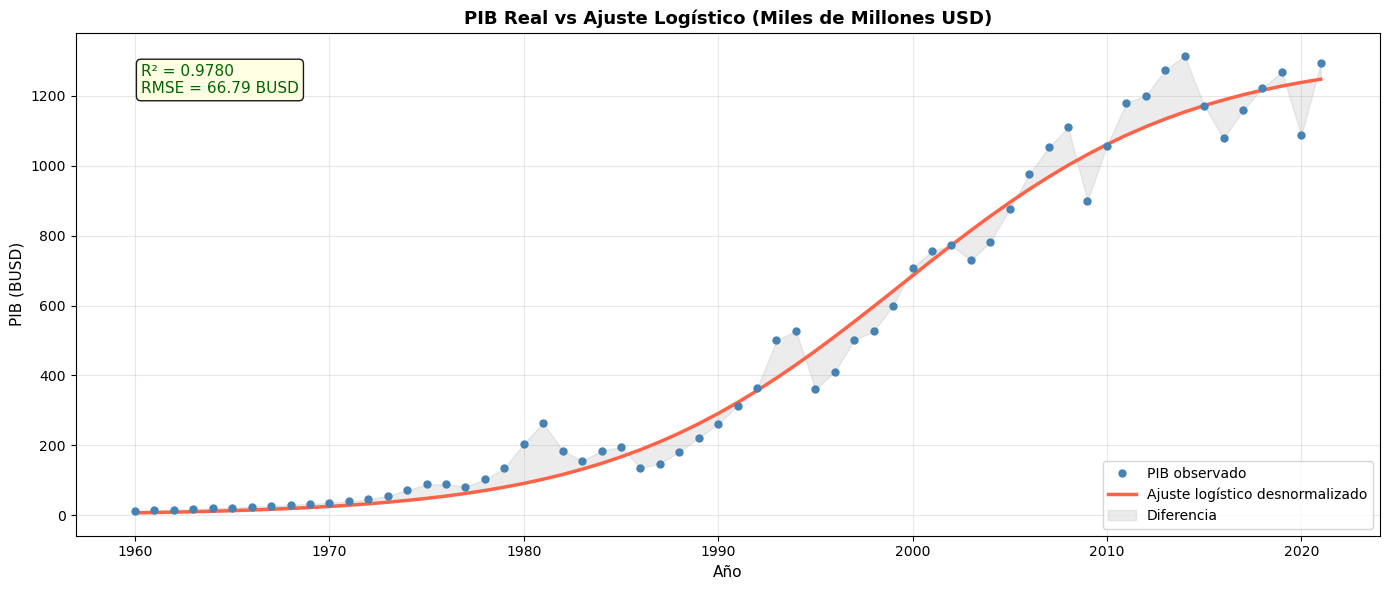

In [10]:
# ============================================================
# COMPARATIVA: AJUSTE EN ESCALA ORIGINAL (DESNORMALIZADO)
# ============================================================

# Desnormalizar predicciones
Y_pred_usd = Y_pred_norm * max_Y_ajustado

# Gráfica: Escala original (desnormalizado)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['Periodo'], df['GDP'] / 1e9,
         'o', color='steelblue', markersize=5,
         label='PIB observado', zorder=5)
ax.plot(df['Periodo'], Y_pred_usd / 1e9,
         '-', color='tomato', linewidth=2.5,
         label='Ajuste logístico desnormalizado')
ax.fill_between(df['Periodo'],
                 df['GDP'].values / 1e9,
                 Y_pred_usd / 1e9,
                 alpha=0.15, color='gray', label='Diferencia')
ax.set_title('PIB Real vs Ajuste Logístico (Miles de Millones USD)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('PIB (BUSD)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.88,
         f'R² = {r2:.4f}\nRMSE = {rmse * max_Y_ajustado / 1e9:.2f} BUSD',
         transform=ax.transAxes, fontsize=11, color='darkgreen',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('ajuste_logistico_desnormalizado.png', dpi=150)
plt.show()

# Gráfica de Residuales del ajuste

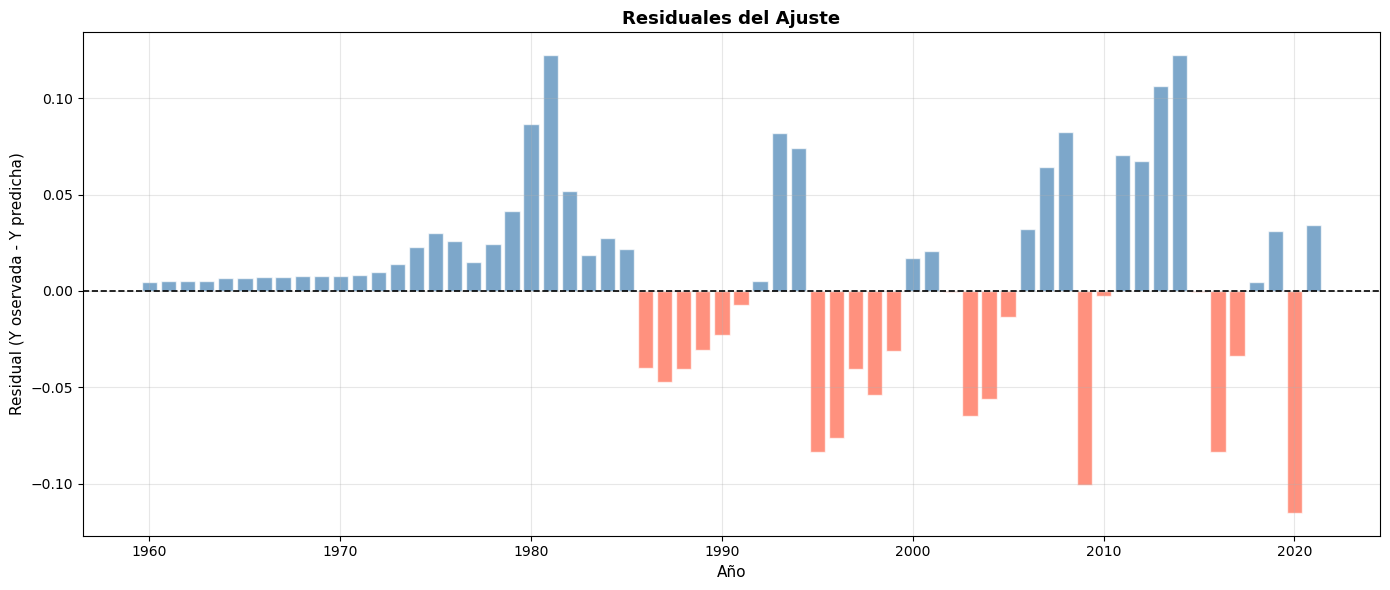

In [23]:
# ============================================================
# VISUALIZACIÓN DE RESIDUALES DEL AJUSTE
# Residual = Valor Observado - Valor Predicho
# ============================================================

residuales = Y_norm - Y_pred_norm

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(df['Periodo'], residuales, color=np.where(residuales >= 0, 'steelblue', 'tomato'),
alpha=0.7, edgecolor='white')
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_title('Residuales del Ajuste', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Residual (Y oservada - Y predicha)', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuales_ajuste.png', dpi=150)
plt.show()

# Pronóstico para 2022

In [14]:
# ============================================================
# PRONÓSTICO DEL PIB DE MÉXICO PARA 2022
# ============================================================

print('=' * 65)
print("PRONÓSTICO PIB MÉXICO - AÑO 2022")
print('=' * 65)

año_pronostico = 2022

# PASO 1: Normalizar el año de pronóstico usando los mismos min_X y max_X
X_2022_norm = (año_pronostico - min_X) / (max_X - min_X)

print(f'\nMECANISMO DE TRANSFORMACIÓN:')
print(f'  1. Normalizar el año:')
print(f"     X_norm = ({año_pronostico} - {min_X}) / ({max_X} - {min_X})")
print(f"     X_norm = {año_pronostico - min_X} / {max_X - min_X}")
print(f"     X_norm = {X_2022_norm:.6f}")

# PASO 2: Aplicar modelo logístico
Y_2022_norm = modelo_logistico(X_2022_norm, beta1_norm, beta2_norm)

print(f"  2. Modelo logístico:")
print(f"     Y_norm = 1 / (1 + exp({beta1_norm:.4f} + {beta2_norm:.4f} × {X_2022_norm:.6f}))")
print(f"     Y_norm = {Y_2022_norm:.8f}")

# PASO 3: Desnormalizar
Y_2022_usd = Y_2022_norm * max_Y_ajustado

print(f'  3. Desnormalizar el resultado:')
print(f"     PIB_2022 = {Y_2022_norm:.8f} × ${max_Y_ajustado:,.2f}")

# PRONÓSTICO
print(f'\n{"─" * 55}')
print(f'PRONÓSTICO PIB MÉXICO 2022:')
print(f'  ${Y_2022_usd:,.2f} USD')
print(f'  (≈ ${Y_2022_usd/1e12:.4f} billones USD)')
print(f'{"─" * 55}')

PRONÓSTICO PIB MÉXICO - AÑO 2022

MECANISMO DE TRANSFORMACIÓN:
  1. Normalizar el año:
     X_norm = (2022 - 1960) / (2021 - 1960)
     X_norm = 62 / 61
     X_norm = 1.016393
  2. Modelo logístico:
     Y_norm = 1 / (1 + exp(5.2842 + -8.1848 × 1.016393))
     Y_norm = 0.95411811
  3. Desnormalizar el resultado:
     PIB_2022 = 0.95411811 × $1,316,666,534,708.07

───────────────────────────────────────────────────────
PRONÓSTICO PIB MÉXICO 2022:
  $1,256,255,390,036.99 USD
  (≈ $1.2563 billones USD)
───────────────────────────────────────────────────────


# Gráfica con pronóstico 2022

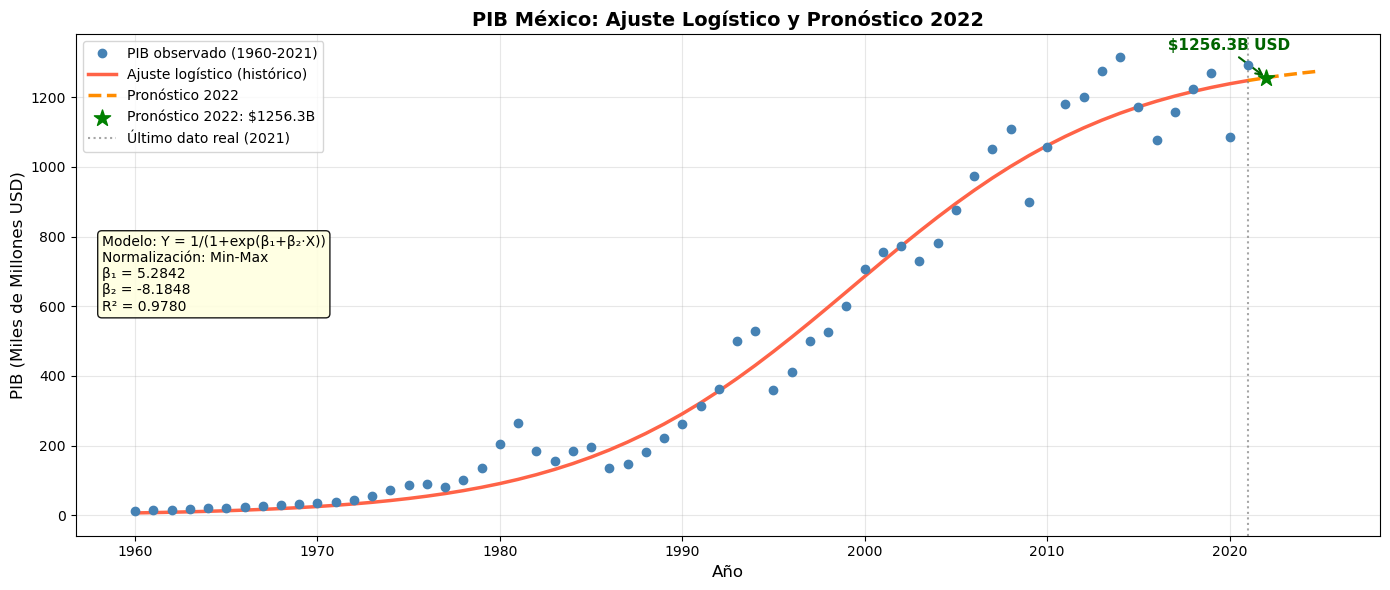

In [25]:
# ============================================================
# VISUALIZACIÓN DE PRONÓSTICO 2022
# ============================================================

# Extender años hasta 2025 para visualizar tendencia
años_ext  = np.arange(1960, 2026)
X_ext_norm = (años_ext - min_X) / (max_X - min_X)
Y_ext_norm = modelo_logistico(X_ext_norm, beta1_norm, beta2_norm)
Y_ext_usd  = Y_ext_norm * max_Y_ajustado

fig, ax = plt.subplots(figsize=(14, 6))

# Datos históricos observados
ax.plot(df['Periodo'], df['GDP'] / 1e9,
        'o', color='steelblue', markersize=6,
        label='PIB observado (1960-2021)', zorder=5)

# Curva ajustada en período histórico (1960-2021)
mask_hist = años_ext <= 2021
ax.plot(años_ext[mask_hist], Y_ext_usd[mask_hist] / 1e9,
        '-', color='tomato', linewidth=2.5,
        label='Ajuste logístico (histórico)')

# Zona de pronóstico (2021-2025)
mask_fut = años_ext >= 2021 # Incluir 2021 en ambas para que la línea sea continua
ax.plot(años_ext[mask_fut], Y_ext_usd[mask_fut] / 1e9,
        '--', color='darkorange', linewidth=2.5,
        label='Pronóstico 2022')

# Punto destacado: pronóstico 2022
ax.scatter([2022], [Y_2022_usd / 1e9],
           color='green', s=150, zorder=10, marker='*',
           label=f'Pronóstico 2022: ${Y_2022_usd/1e9:.1f}B')
# Etiqueta para el punto
ax.annotate(
    f'  ${Y_2022_usd/1e9:.1f}B USD',
    xy = (2022, Y_2022_usd / 1e9),
    xytext = (2016, Y_2022_usd / 1e9 + 80), # posición del texto
    fontsize=11, color='darkgreen', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5)
)

# Línea vertical para separar histórico de pronóstico
ax.axvline(x=2021, color='gray', linestyle=':', 
           alpha=0.7, label='Último dato real (2021)')

# Etiquetas y formato
ax.set_title('PIB México: Ajuste Logístico y Pronóstico 2022',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('PIB (Miles de Millones USD)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# Caja de parámetros del modelo
ax.text(
    0.02, 0.60,
    f'Modelo: Y = 1/(1+exp(β₁+β₂·X))\n'
    f'Normalización: Min-Max\n'
    f'β₁ = {beta1_norm:.4f}\n'
    f'β₂ = {beta2_norm:.4f}\n'
    f'R² = {r2:.4f}',
    transform=ax.transAxes,
    fontsize=10, color='black',
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)

# Ajustar, guardar y mostrar
plt.tight_layout()
plt.savefig('pronostico_2022.png', dpi=150)
plt.show()

# Resumen final y conclusiones

In [26]:
# ============================================================
# RESUMEN FINAL Y CONCLUSIONES
# Regresión Logística - PIB México (1960-2021)
# ============================================================

print('=' * 65)
print("RESUMEN Y CONCLUSIONES - REGRESIÓN LOGÍSTICA PIB MX")
print('=' * 65)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. MODELO UTILIZADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  El modelo ajustado es el modelo logístico de la forma:

            Y = 1 / (1 + exp(β₁ + β₂·X))

  Donde:
    X = Periodo (año normalizado)
    Y = PIB de México (normalizado)
    β₁, β₂ = parámetros estimados por mínimos cuadrados
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 2. PROBLEMAS EN LA ESTIMACIÓN DE PARÁMETROS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  PROBLEMA 1 → Datos sin normalizar
    El modelo logístico produce valores únicamente en (0,1):
    • El PIB real está en escala de 10¹² (billones de USD)
    • Resultado: R² = -1.165  →  ajuste completamente fallido
    • El optimizador devolvió los valores iniciales sin modificarlos, porque ningún β₁, β₂ 
      puede hacer que Y = 1/(1+eˣ) alcance valores de 10¹²

  PROBLEMA 2 → Normalización incorrecta (división simple entre el máximo)
    Al dividir X entre max(X): X_norm = año / 2021:
    • Rango resultante: [0.9698, 1.0000]
    • Los años quedaban "apretados" en un rango de 0.03
    • El modelo no podía distinguir entre 1960 y 2021
    • Resultado: β₁ = 1308, β₂ = -1256  (±inf)
    • R² = -1.165  →  ajuste fallido nuevamente
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 3. PROCESO DE NORMALIZACIÓN CORRECTO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Para X (años) → Normalización Min-Max:
    • X_norm = (año - año_min) / (año_max - año_min)
    • X_norm = (año - 1960) / (2021 - 1960)
    • Rango resultante: [0.0000, 1.0000]
    • El modelo puede distinguir toda la evolución temporal

  Para Y (PIB) → División por máximo ajustado:
    • Y_norm = PIB / (max_PIB × 1.001)
    • Rango resultante: [0.0099, 0.9990]

  ¿Por qué no se usa Min-Max en Y?
    → Min-Max llevaría Y exactamente a 0.0 y 1.0 
    → El modelo logístico nunca puede alcanzar 0 ni 1
    → Los parámetros divergirían a ±infinito

  ¿Por qué × 1.001?
    → Empuja el máximo ligeramente por debajo de 1.0
    → Garantiza que 0 < Y_norm < 1  estrictamente
    → Permite la convergencia del optimizador
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 4. PARÁMETROS ESTIMADOS (normalización corregida)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f"  Método de estimación: Mínimos Cuadrados No Lineales")
print(f"                         (scipy.optimize.curve_fit,")
print(f"                          algoritmo Levenberg-Marquardt)")
print(f"\n  β₁ = {beta1_norm:.6f}")
print(f"  β₂ = {beta2_norm:.6f}")
print(f"\n  Modelo final (datos normalizados):")
print(f"  Y_norm = 1 / (1 + exp({beta1_norm:.4f} + {beta2_norm:.4f}·X_norm))")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 5. BONDAD DE AJUSTE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f'   R²          = {r2:.6f} → {'★ Excelente' if r2>0.95 else '✓ Bueno' if r2>0.85 else '✗ Revisar'}')
print(f'   R (Pearson) = {r_pearson:.6f} (p = {p_valor:.2e})')
print(f'   RMSE (norm) = {rmse:.6f}')
print(f'   MAE (norm)  = {mae:.6f}')
print(f'   SS_res      = {ss_res:.6e}')
print(f'   SS_tot      = {ss_tot:.6e}')

print(f"""
  Interpretación:
    ✦ R² = {r2:.4f} indica que el modelo logístico explica el {r2*100:.2f}% de la variabilidad 
      del PIB de México en el período 1960-2021.
    ✦ La correlación de Pearson de {r_pearson:.4f} confirma una relación muy fuerte entre los 
      valores observados y los predichos por el modelo.
    ✦ El RMSE de {rmse:.4f} (en escala normalizada) refleja un error promedio pequeño y aceptable.
""")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 6. PRONÓSTICO PIB MÉXICO 2022
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Mecanismo de transformación para el pronóstico:

  PASO 1 → Normalizar el año con los mismos parámetros del entrenamiento:
           X_norm = (2022 - {min_X}) / ({max_X} - {min_X})
           X_norm = {(2022-min_X)/(max_X-min_X):.6f}

  PASO 2 → Aplicar el modelo logístico:
           Y_norm = 1 / (1 + exp({beta1_norm:.4f} + {beta2_norm:.4f} × {(2022-min_X)/(max_X-min_X):.6f}))
           Y_norm = {Y_2022_norm:.8f}

  PASO 3 → Desnormalizar (misma escala del entrenamiento):
           PIB_2022 = Y_norm × (max_PIB × 1.001)
           PIB_2022 = {Y_2022_norm:.8f} × ${max_Y_ajustado:,.2f}
""")
print(f"  Pronóstico PIB México 2022:")
print(f"   ${Y_2022_usd:,.2f} USD")
print(f"   ≈ ${Y_2022_usd/1e12:.4f} billones USD")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 7. CONCLUSIÓN GENERAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ✓ El modelo logístico logró un ajuste satisfactorio una vez aplicada la normalización correcta.
  ✓ La normalización Min-Max en X y la división por max_Y × 1.001 en Y fueron pasos indispensables 
    para garantizar la convergencia del optimizador.
  ✓ Con R² = {r2:.4f}, el modelo explica adecuadamente la tendencia histórica del PIB mexicano 
    en el período 1960-2021.

  → Limitaciones del modelo logístico para este caso:
    1. Asume que el PIB tiene un valor máximo (saturación) lo cual puede no reflejar la realidad 
       económica de largo plazo.
    2. No captura bien los ciclos económicos ni las caídas abruptas (1982, 1995, 2009, 2020).
    3. Los pronósticos más allá del período de entrenamiento deben interpretarse con precaución, 
       especialmente porque X_norm > 1.0 implica extrapolación fuera del rango observado.
    4. Para pronósticos más precisos se recomendaría explorar modelos de series de tiempo (ARIMA) 
       o modelos polinomiales de mayor orden.
""")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Fuente de datos Otorgados por EBAC tomados de Banco Mundial
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

RESUMEN Y CONCLUSIONES - REGRESIÓN LOGÍSTICA PIB MX

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. MODELO UTILIZADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  El modelo ajustado es el modelo logístico de la forma:

            Y = 1 / (1 + exp(β₁ + β₂·X))

  Donde:
    X = Periodo (año normalizado)
    Y = PIB de México (normalizado)
    β₁, β₂ = parámetros estimados por mínimos cuadrados


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 2. PROBLEMAS EN LA ESTIMACIÓN DE PARÁMETROS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  PROBLEMA 1 → Datos sin normalizar
    El modelo logístico produce valores únicamente en (0,1):
    • El PIB real está en escala de 10¹² (billones de USD)
    • Resultado: R² = -1.165  →  ajuste completamente fallido
    • El optimizador devolvió los valores iniciales sin modificarlos, porque ningún β₁, β₂ 
      puede hacer que Y = 1/(1+eˣ) alcance valores de 10¹²

  PROBLEMA 2